In [ ]:
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch_geometric

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 62.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 108.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 67.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 54.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.8 MB/s eta 0:00:00


## New Heat Map from Scratch
This code here was used to generate the main heatmap for the paper

=== RDP-Derived Epsilon Calculator (Log-Domain Safe) ===

---------------------------------------------
Number of Features Considered = 25
Alpha Values considered = 2
Lowest RDP-derived ε: 147.7060 | Mean Direct ε: 227.8550

Alpha Values considered = 10
Lowest RDP-derived ε: 136.9299 | Mean Direct ε: 227.8550

Alpha Values considered = 20
Lowest RDP-derived ε: 138.3943 | Mean Direct ε: 227.8550

Alpha Values considered = 30
Lowest RDP-derived ε: 138.8489 | Mean Direct ε: 227.8550

Alpha Values considered = 40
Lowest RDP-derived ε: 139.0705 | Mean Direct ε: 227.8550

Alpha Values considered = 50
Lowest RDP-derived ε: 139.2017 | Mean Direct ε: 227.8550

Alpha Values considered = 60
Lowest RDP-derived ε: 139.2885 | Mean Direct ε: 227.8550

Alpha Values considered = 80
Lowest RDP-derived ε: 139.3962 | Mean Direct ε: 227.8550


Difference heatmap saved as: rdp_difference_heatmap_delta_only_25features.png


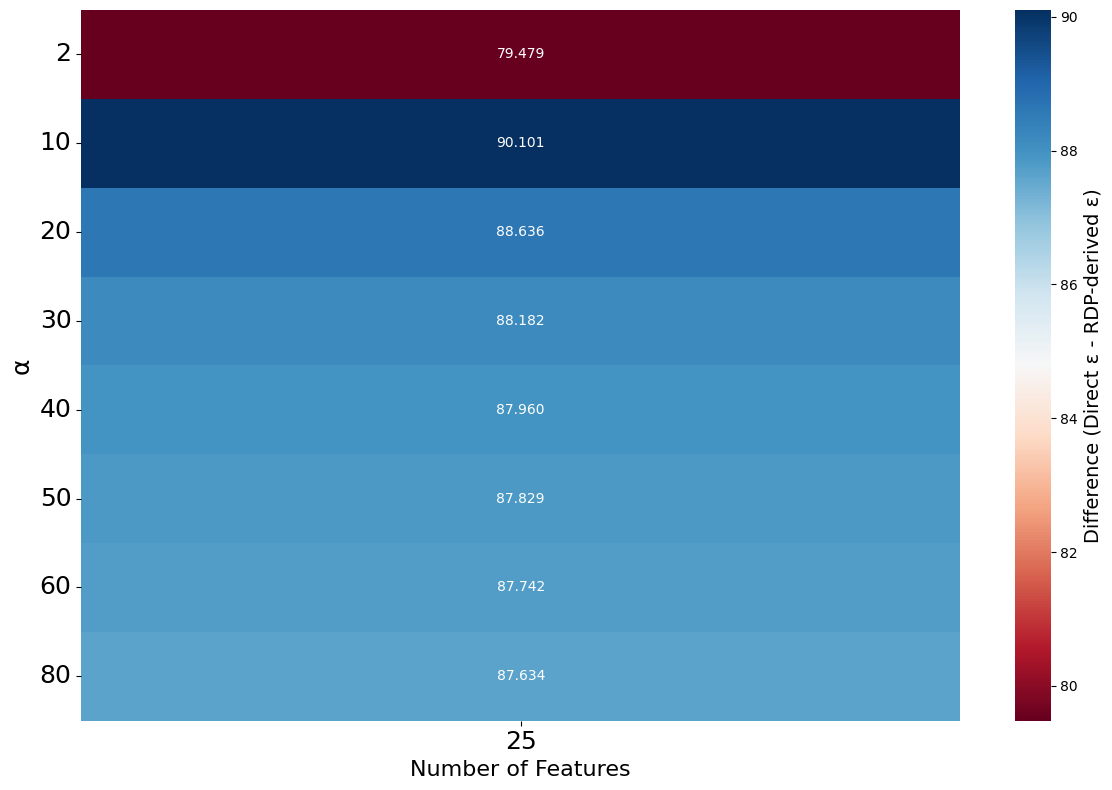

In [ ]:
from enum import NAMED_FLAGS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============ CONFIGURATION ============
# epsilon values set based on budget allocated to the different levels of privacy
EPSILON_1 = 5
EPSILON_2 = 6
EPSILON_3 = 10
NAME_TAG = "set_your_preferred_tag"

NUMBER_OF_RECORDS_CONSIDERED = 1000
RANGE_OF_NUMBER_OF_FEATURES_CONSIDERED = [25] # in order to observe budget constriction for the different number of features


FILE_EPSILON_ASSIGNMENTS = "/content/pubmed_probabilistic_data.csv" # contains the different budgets allocated to different entries
FILE_FEATURE_PARAMETERS = "/content/privacy_parameters_output.csv" # contains the optimized parameter values found from matlab pg3
FILE_FEATURE_DOMAINS = "/content/pubmed_unique_counts.csv" # number of unique counts of different classes or categories

ALPHA_VALUES = [2, 10, 20, 30, 40, 50, 60, 80] # set your preferred alpha values for conversion
DELTA = 1e-5
# =======================================

def create_difference_heatmap(heatmap_df, feature_counts, alpha_values, expected_epsilons, name_tag):
    """Create and save the difference heatmap."""

    # Prepare data for heatmap
    alpha_cols = [f'alpha_{alpha}' for alpha in alpha_values]
    heatmap_matrix = heatmap_df[alpha_cols].values

    # Create the heatmap
    plt.figure(figsize=(12, 8))

    # Use a dynamic range based on actual data
    vmin = heatmap_matrix.min()
    vmax = heatmap_matrix.max()

    # Center the colormap at 0 if the range spans across 0, otherwise use the data range
    if vmin < 0 < vmax:
        center = 0.0
        abs_max = max(abs(vmin), abs(vmax))
        vmin, vmax = -abs_max, abs_max
    else:
        center = (vmin + vmax) / 2

    ax = sns.heatmap(heatmap_matrix.T,  # Transpose to swap axes
                xticklabels=feature_counts,
                yticklabels=alpha_values,
                annot=True,
                fmt='.3f',
                cmap='RdBu',
                center=center,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': 'Difference (Direct ε - RDP-derived ε)'})

    ax.collections[0].colorbar.ax.yaxis.label.set_size(14)
    plt.xlabel('Number of Features', fontsize=16)
    plt.ylabel('α', fontsize=18)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=0, fontsize=18)
    plt.yticks(rotation=0, fontsize=18)

    plt.tight_layout()

    # Save as high DPI PNG
    filename = f"rdp_difference_heatmap_delta_"+ name_tag +".png"
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"\nDifference heatmap saved as: {filename}")

    plt.show()

    return filename

def compute_rdp_grr(p_list, q_list, d, alpha, user_eps_idx):
    """
    Compute worst-case RDP for GRR in the LOG DOMAIN to avoid OverflowError.
    Returns the log of the moment (not divided by alpha-1 yet).
    """
    if alpha <= 1:
        return 0

    i = user_eps_idx
    p_i, q_i = p_list[i], q_list[i]

    # Handle edge case where probabilities are zero
    if p_i <= 0 or q_i <= 0:
        return -np.inf

    max_log_moment = -np.inf

    for k in range(len(p_list)):
        if k == i:
            continue  # skip comparing with self

        p_k, q_k = p_list[k], q_list[k]

        if p_k <= 0 or q_k <= 0:
            continue

        # We calculate log terms directly: log(x^a * y^b) = a*log(x) + b*log(y)

        # Term 1: p_i^alpha * q_k^(1-alpha)
        # Add epsilon to log inputs to prevent log(0)
        log_term1 = alpha * np.log(p_i + 1e-15) + (1 - alpha) * np.log(q_k + 1e-15)

        # Term 2: q_i^alpha * p_k^(1-alpha)
        log_term2 = alpha * np.log(q_i + 1e-15) + (1 - alpha) * np.log(p_k + 1e-15)

        # Term 3: (d - 2) * q_i^alpha * q_k^(1-alpha)
        if d > 2:
            log_term3 = np.log(d - 2) + alpha * np.log(q_i + 1e-15) + (1 - alpha) * np.log(q_k + 1e-15)
            # Combine all three terms using logaddexp (log(e^a + e^b + e^c))
            current_log_moment = np.logaddexp(log_term1, np.logaddexp(log_term2, log_term3))
        else:
            # If d=2, the third term is 0 (which is -inf in log space), so we just sum term1 and term2
            current_log_moment = np.logaddexp(log_term1, log_term2)

        max_log_moment = max(max_log_moment, current_log_moment)

    return max_log_moment

def compute_rdp_idue(a_list, b_list, alpha, user_eps_idx):
    """
    Compute worst-case RDP for IDUE in the LOG DOMAIN to avoid OverflowError.
    Returns the log of the moment.
    """
    if alpha <= 1:
        return 0

    i = user_eps_idx
    a_i, b_i = a_list[i], b_list[i]

    max_log_moment = -np.inf

    for k in range(len(a_list)):
        if k == i:
            continue  # skip comparing with self

        a_k, b_k = a_list[k], b_list[k]

        # Helper to safely compute log(term^alpha * other^(1-alpha))
        def log_part(val1, val2):
            return alpha * np.log(val1 + 1e-15) + (1 - alpha) * np.log(val2 + 1e-15)

        # Calculate the 4 components of IDUE in log domain
        l1 = log_part(a_i * b_k, b_i * a_k)
        l2 = log_part(a_i * (1 - b_k), b_i * (1 - a_k))
        l3 = log_part((1 - a_i) * b_k, (1 - b_i) * a_k)
        l4 = log_part((1 - a_i) * (1 - b_k), (1 - b_i) * (1 - a_k))

        # Sum them up: log(e^l1 + e^l2 + e^l3 + e^l4)
        current_log_moment = np.logaddexp(l1, np.logaddexp(l2, np.logaddexp(l3, l4)))

        max_log_moment = max(max_log_moment, current_log_moment)

    return max_log_moment

def find_closest_epsilon(val, expected, tol=0.05):
    """Find matching epsilon within tolerance."""
    for eps in expected:
        if abs(val - eps) < tol:
            return eps
    return None

def main():
    print("=== RDP-Derived Epsilon Calculator (Log-Domain Safe) ===\n")

    expected_epsilons = sorted([EPSILON_1, EPSILON_2, EPSILON_3])

    # Load data
    epsilon_df = pd.read_csv(FILE_EPSILON_ASSIGNMENTS).set_index('user_id')
    feature_cols = [col for col in epsilon_df.columns if col.startswith('feature_')]
    epsilon_df = epsilon_df[feature_cols]

    params_df = pd.read_csv(FILE_FEATURE_PARAMETERS)
    params_df['feature'] = [f'feature_{i}' for i in range(len(params_df))]

    domain_df = pd.read_csv(FILE_FEATURE_DOMAINS)
    if 'Feature' in domain_df.columns:
        domain_df = domain_df.rename(columns={'Feature': 'feature', 'Unique_Values': 'domain_size'})
    if domain_df['feature'].dtype in ['int64', 'float64']:
        domain_df['feature'] = [f'feature_{int(x)}' for x in domain_df['feature']]

    # Create lookups
    params_dict = {row['feature']: row.to_dict() for _, row in params_df.iterrows()}
    domain_dict = dict(zip(domain_df['feature'], domain_df['domain_size']))

    # Collect data for heatmap
    heatmap_data = {f'alpha_{alpha}': [] for alpha in ALPHA_VALUES}
    feature_counts = RANGE_OF_NUMBER_OF_FEATURES_CONSIDERED

    print("-" * 45)
    for NUMBER_OF_FEATURES_CONSIDERED in RANGE_OF_NUMBER_OF_FEATURES_CONSIDERED:
        print("Number of Features Considered = " + str(NUMBER_OF_FEATURES_CONSIDERED))
        for ALPHA in ALPHA_VALUES:
            print("Alpha Values considered = " + str(ALPHA) )
            differences = []
            rdp_epsilons = []
            for user_id in epsilon_df.index[:NUMBER_OF_RECORDS_CONSIDERED]:
                total_rdp = 0
                total_eps = 0
                for feature in feature_cols[:NUMBER_OF_FEATURES_CONSIDERED]:
                    eps_val = epsilon_df.loc[user_id, feature]
                    total_eps = total_eps + eps_val
                    matched_eps = find_closest_epsilon(eps_val, expected_epsilons)
                    if pd.isna(eps_val) or matched_eps is None or feature not in params_dict:
                        continue

                    p = params_dict[feature]
                    d = domain_dict.get(feature, 2)
                    eps_idx = expected_epsilons.index(matched_eps)

                    # Compute RDP (Log Moments)
                    log_rdp_grr = compute_rdp_grr(
                        [p['p1'], p['p2'], p['p3']],
                        [p['q1'], p['q2'], p['q3']],
                        d,
                        ALPHA,
                        eps_idx
                    )
                    log_rdp_idue = compute_rdp_idue(
                        [p['a1'], p['a2'], p['a3']],
                        [p['b1'], p['b2'], p['b3']],
                        ALPHA,
                        eps_idx
                    )

                    # Mixture combination in Log Domain
                    # formula: log( alpha1 * exp(GRR) + (1-alpha1) * exp(IDUE) )
                    log_weighted_grr = np.log(p['alpha1'] + 1e-15) + log_rdp_grr
                    log_weighted_idue = np.log(1 - p['alpha1'] + 1e-15) + log_rdp_idue

                    mixture_log_moment = np.logaddexp(log_weighted_grr, log_weighted_idue)

                    # Add to total RDP (multiply by 1/(alpha-1))
                    total_rdp += (1/(ALPHA-1)) * mixture_log_moment

                eps_from_rdp = total_rdp + np.log(1/DELTA) / (ALPHA - 1)
                differences.append(total_eps - eps_from_rdp)
                rdp_epsilons.append(eps_from_rdp)

            # Store average difference for this (feature_count, alpha) combination
            heatmap_data[f'alpha_{ALPHA}'].append(np.mean(differences))
            print(f"Lowest RDP-derived ε: {np.min(rdp_epsilons):.4f} | Mean Direct ε: {np.mean(rdp_epsilons) + np.mean(differences):.4f}\n")

    # Create heatmap dataframe
    heatmap_df = pd.DataFrame(heatmap_data)

    # Create the heatmap
    create_difference_heatmap(heatmap_df, feature_counts, ALPHA_VALUES, expected_epsilons, NAME_TAG)

if __name__ == "__main__":
    main()

In [ ]:
import os
os.remove("/content/privacy_parameters_output.csv")
os.remove("/content/pubmed_unique_counts.csv")
os.remove("/content/pubmed_probabilistic_data.csv")